In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
data_path="../data/T2_Mouse_Brain_Slideseq_Puck21082401/"
adata_raw=sc.read(data_path+"adata_anno.h5ad")
label_df=pd.read_csv(data_path+"adata_obs_anno.csv", index_col=0)

adata=sc.read_loom(data_path+"Puck_210824_01_ZNHHZ.loom")
adata.obs.index = adata.obs.index.str.replace("Puck_210824_01_ZNHHZ:", "", regex=False)

common_idx = adata.obs.index.intersection(adata_raw.obs.index)
label_df=label_df.loc[common_idx].copy()
adata_raw=adata_raw[common_idx].copy()
adata=adata[common_idx].copy()

adata.obs[['xcoord', 'ycoord', 'label']]=label_df.loc[label_df.index, ['xcoord', 'ycoord', 'annotation']]
adata.obs['label'] = adata.obs['label'].astype(str)
adata.obsm["spatial"] = adata.obs[['xcoord', 'ycoord']].to_numpy()

# Run model

In [3]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.75 0.22 0.03]


AnnData object with n_obs × n_vars = 10686 × 56305
    obs: 'xcoord', 'ycoord', 'label'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'spatial'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [4]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=50, n_neighbors=30)

Filtered out 54654 genes that are detected 2 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:29) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [5]:
stv.Cal_Spatial_Net(adata, rad_cutoff=80)

------Calculating spatial graph...
The graph contains 180068 edges, 10686 cells.
16.8508 neighbors per cell on average.


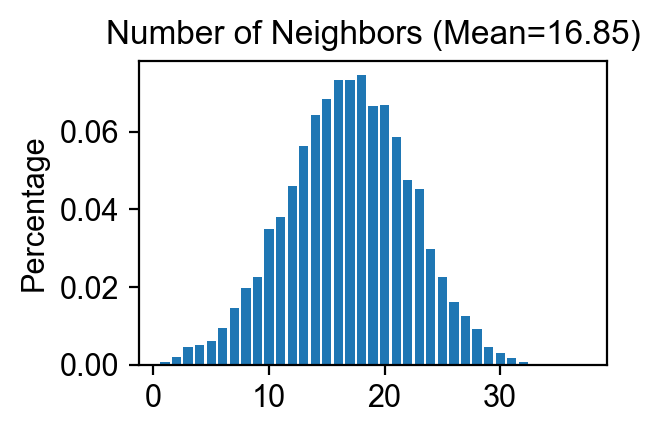

In [6]:
stv.Stats_Spatial_Net(adata)

In [7]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:2')

Size of Input:  (10680, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:35<00:00, 27.91it/s]


In [8]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/10680 [00:00<?, ?cells/s]

    finished (0:00:28) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [9]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


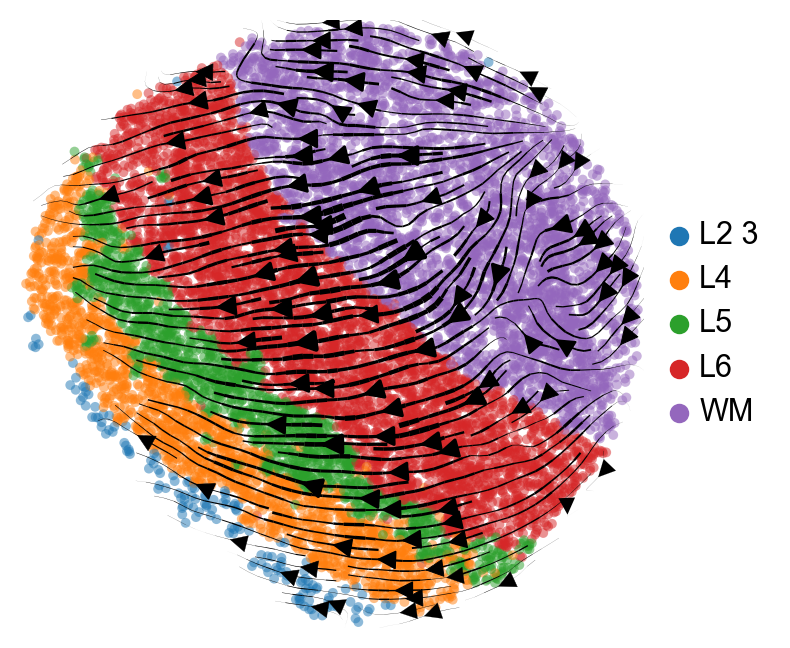

In [10]:
plt.rcParams["figure.figsize"] = (4, 4)
stv.velocity_embedding_stream(adata, basis='spatial', color="label", title="", legend_loc="right", alpha=0.5, size=50, 
                              linewidth=1.5, arrow_size=1.5)

In [11]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")